# Quels facteurs sont associés à la régularité des TGV en France ?

**Réalisé par :** Saima Bessrour – Sarra Chamsi – Yarbana Cheikh Mohamed Vadel  
**Projet final – Python pour la data science**  
**Année universitaire 2025-2026**

# 1-Introduction

La ponctualité ferroviaire est un enjeu majeur pour les usagers comme pour les opérateurs de transport.  
Dans ce projet, nous exploitons les données mensuelles de régularité des TGV publiées par la SNCF afin d'étudier les facteurs associés à la régularité à l'arrivée.

Notre objectif est double :
- décrire les grandes tendances de la régularité des TGV en France ;
- identifier les variables les plus associées à cette régularité à l'aide d'une modélisation statistique.

Nous nous intéressons en particulier au rôle :
- de la ligne ;
- de la temporalité (mois, année, saison) ;
- du trafic ;
- des causes de retard.

# Chargement des bibliothèques

Nous commençons par importer les bibliothèques nécessaires à l’analyse, à la visualisation et à la modélisation, ainsi que les fonctions utilitaires définies dans `utils.py`, notamment pour la création des saisons et certains graphiques.

In [ ]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from great_tables import GT
from utils import get_saison, plot_regularite_moyenne

# 2- Traitement des données:

## 2.1 Importation des données
Nous chargeons le jeu de données portant sur la régularité mensuelle des TGV.

In [2]:

# Date limite de données
date = '2026-01-21'  # date de l'export csv télchargeable sur le site
# On fixe une date limite pour figer le périmètre temporel de l'analyse
# et garantir la reproductibilité des résultats.
url = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/regularite-mensuelle-tgv-aqst/exports/csv"
params = {
    "where": f"date <= '{date}'",
    "sort": "date",
}


response = requests.get(url, params=params)

# response.content contient le CSV depuis l'API
df = pd.read_csv(BytesIO(response.content), sep=";")
df.head()

,date,service,gare_depart,gare_arrivee,duree_moyenne,nb_train_prevu,nb_annulation,commentaire_annulation,nb_train_depart_retard,retard_moyen_depart,...,nb_train_retard_sup_15,retard_moyen_trains_retard_sup15,nb_train_retard_sup_30,nb_train_retard_sup_60,prct_cause_externe,prct_cause_infra,prct_cause_gestion_trafic,prct_cause_materiel_roulant,prct_cause_gestion_gare,prct_cause_prise_en_charge_voyageurs
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,32,5.363539,9,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386


## 2.2 Exploration du jeu de données:

Afin de mieux comprendre la structure du jeu de données, nous examinons la liste des variables disponibles.  
Cela permet d’identifier les informations exploitables pour l’analyse, ainsi que les éventuelles transformations à effectuer.

In [3]:
df.columns.tolist()

['date',
 'service',
 'gare_depart',
 'gare_arrivee',
 'duree_moyenne',
 'nb_train_prevu',
 'nb_annulation',
 'commentaire_annulation',
 'nb_train_depart_retard',
 'retard_moyen_depart',
 'retard_moyen_tous_trains_depart',
 'commentaire_retards_depart',
 'nb_train_retard_arrivee',
 'retard_moyen_arrivee',
 'retard_moyen_tous_trains_arrivee',
 'commentaires_retard_arrivee',
 'nb_train_retard_sup_15',
 'retard_moyen_trains_retard_sup15',
 'nb_train_retard_sup_30',
 'nb_train_retard_sup_60',
 'prct_cause_externe',
 'prct_cause_infra',
 'prct_cause_gestion_trafic',
 'prct_cause_materiel_roulant',
 'prct_cause_gestion_gare',
 'prct_cause_prise_en_charge_voyageurs']

Afin de compléter cette première exploration, nous examinons le type des variables ainsi que le nombre de valeurs non nulles.  
Cela permet d’identifier les variables numériques, catégorielles, ainsi que la présence éventuelle de valeurs manquantes.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11834 entries, 0 to 11833
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  11834 non-null  object 
 1   service                               11834 non-null  object 
 2   gare_depart                           11834 non-null  object 
 3   gare_arrivee                          11834 non-null  object 
 4   duree_moyenne                         11834 non-null  int64  
 5   nb_train_prevu                        11834 non-null  int64  
 6   nb_annulation                         11834 non-null  int64  
 7   commentaire_annulation                0 non-null      float64
 8   nb_train_depart_retard                11834 non-null  int64  
 9   retard_moyen_depart                   11834 non-null  float64
 10  retard_moyen_tous_trains_depart       11834 non-null  float64
 11  commentaire_ret

Le jeu de données comporte 11 834 observations et 26 variables.  
Il contient à la fois des variables catégorielles (`Service`, gares de départ et d'arrivée), des variables numériques liées au trafic et aux retards, ainsi que quelques colonnes de commentaires.

La variable `Date` est actuellement stockée sous forme de texte (`object`). Elle sera convertie en format datetime dans l’étape de préparation des variables temporelles.  
Par ailleurs, certaines colonnes de commentaires sont entièrement ou presque entièrement vides ; elles ne seront donc pas exploitées dans un premier temps.

## 2.3 Analyse et traitement des valeurs manquantes

Nous examinons la présence de valeurs manquantes dans le jeu de données afin d’identifier les variables nécessitant un traitement particulier.

In [5]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

commentaire_annulation                  100.0
commentaire_retards_depart              100.0
commentaires_retard_arrivee              94.1
gare_depart                               0.0
service                                   0.0
gare_arrivee                              0.0
nb_train_prevu                            0.0
nb_annulation                             0.0
duree_moyenne                             0.0
date                                      0.0
retard_moyen_depart                       0.0
nb_train_depart_retard                    0.0
nb_train_retard_arrivee                   0.0
retard_moyen_tous_trains_depart           0.0
retard_moyen_arrivee                      0.0
retard_moyen_tous_trains_arrivee          0.0
nb_train_retard_sup_15                    0.0
retard_moyen_trains_retard_sup15          0.0
nb_train_retard_sup_30                    0.0
nb_train_retard_sup_60                    0.0
prct_cause_externe                        0.0
prct_cause_infra                  

L’analyse des valeurs manquantes montre que le jeu de données est presque entièrement complet sur les variables utiles à l’étude.
Seules les colonnes de commentaires présentent un fort taux de valeurs manquantes : deux sont totalement vides et une troisième est absente dans plus de 94 % des observations.

Ces colonnes textuelles ne seront donc pas exploitées dans la suite de l’analyse.

En complément, une vérification des modalités des variables catégorielles a permis d’identifier des valeurs aberrantes, notamment la présence de "0" dans `gare_depart` et `gare_arrivee`.
Ces valeurs ont été assimilées à des données manquantes puis traitées comme telles.


In [6]:
# Vérification des modalités de la variable gare_depart
df["gare_depart"].sort_values().unique()

array(['0', 'AIX EN PROVENCE TGV', 'ANGERS SAINT LAUD', 'ANGOULEME',
       'ANNECY', 'ARRAS', 'AVIGNON TGV', 'BARCELONA', 'BELLEGARDE (AIN)',
       'BESANCON FRANCHE COMTE TGV', 'BORDEAUX ST JEAN', 'BREST',
       'CHAMBERY CHALLES LES EAUX', 'DIJON VILLE', 'DOUAI', 'DUNKERQUE',
       'FRANCFORT', 'GENEVE', 'GRENOBLE', 'ITALIE', 'LA ROCHELLE VILLE',
       'LAUSANNE', 'LAVAL', 'LE CREUSOT MONTCEAU MONTCHANIN', 'LE MANS',
       'LILLE', 'LYON PART DIEU', 'MACON LOCHE', 'MADRID',
       'MARNE LA VALLEE', 'MARSEILLE ST CHARLES', 'METZ', 'MONTPELLIER',
       'MULHOUSE VILLE', 'NANCY', 'NANTES', 'NICE VILLE', 'NIMES',
       'PARIS EST', 'PARIS LYON', 'PARIS MONTPARNASSE', 'PARIS NORD',
       'PARIS VAUGIRARD', 'PERPIGNAN', 'POITIERS', 'QUIMPER', 'REIMS',
       'RENNES', 'SAINT ETIENNE CHATEAUCREUX', 'ST MALO',
       'ST PIERRE DES CORPS', 'STRASBOURG', 'STUTTGART', 'TOULON',
       'TOULOUSE MATABIAU', 'TOURCOING', 'TOURS', 'VALENCE ALIXAN TGV',
       'VANNES', 'ZURICH'], dtype=o

In [7]:
# Comptage du nombre de valeurs aberrantes codées "0" dans gare_depart
(df["gare_depart"]=='0').sum()

np.int64(4)

In [8]:
# Nombre de gares de départ distinctes observées dans le jeu de données

df["gare_depart"].nunique()

60

In [9]:
# Comptage du nombre de valeurs aberrantes codées "0" dans gare_arrivee

(df["gare_arrivee"]=='0').sum()

np.int64(12)

In [10]:
df["gare_arrivee"].nunique()

60

In [11]:
# Nombre de lignes avant correction
nb_lignes_avant = len(df)

In [12]:
# Remplacement des valeurs aberrantes par NaN
df["gare_depart"] = df["gare_depart"].replace('0', np.nan)
df["gare_arrivee"] = df["gare_arrivee"].replace('0', np.nan)

In [13]:
# Vérification du nombre de valeurs manquantes créées
print("Valeurs manquantes dans gare_depart :", df["gare_depart"].isna().sum())
print("Valeurs manquantes dans gare_arrivee :", df["gare_arrivee"].isna().sum())

Valeurs manquantes dans gare_depart : 4
Valeurs manquantes dans gare_arrivee : 12


In [14]:
# Suppression des lignes concernées
df= df.dropna(subset=["gare_depart", "gare_arrivee"]).copy()

In [15]:
# Nombre de lignes après correction
nb_lignes_apres = len(df)

In [16]:
print("Nombre de lignes supprimées :", nb_lignes_avant - nb_lignes_apres)
print("Nouvelle dimension du jeu de données :", df.shape)

Nombre de lignes supprimées : 16
Nouvelle dimension du jeu de données : (11818, 26)


Résumé: La valeur "0" observée dans les variables `gare_depart` et `gare_arrivee` ne correspond à aucune gare réelle.
Elle a donc été interprétée comme une valeur manquante, recodée en NaN, puis les observations concernées ont été supprimées.

Une vérification ciblée a été menée sur les variables les plus susceptibles de contenir des modalités incohérentes, en particulier les gares de départ et d’arrivée.
Les autres variables n’ont pas mis en évidence d’anomalies manifestes lors de l’exploration initiale.

# 3-Construction des variables d'analyse :


## 3.1 Préparation des variables temporelles

Afin d'étudier l'évolution de la régularité dans le temps, nous convertissons d'abord la variable `Date` en véritable format date.  
Nous créons ensuite des variables temporelles plus directement exploitables, comme l'année et le mois.

In [17]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m")
df["annee"] = df["date"].dt.year

df["mois"] = df["date"].dt.month

In [18]:
df[["date", "annee", "mois"]].head()

,date,annee,mois
0,2018-01-01,2018,1
1,2018-01-01,2018,1
2,2018-01-01,2018,1
3,2018-01-01,2018,1
4,2018-01-01,2018,1


Afin de compléter les variables temporelles, nous introduisons une variable `saison`, construite à partir du mois.  
Cela permet d’analyser plus facilement les effets saisonniers sur la régularité.

In [19]:
df["saison"] = df["mois"].apply(get_saison)
df.head()

,date,service,gare_depart,gare_arrivee,duree_moyenne,nb_train_prevu,nb_annulation,commentaire_annulation,nb_train_depart_retard,retard_moyen_depart,...,nb_train_retard_sup_60,prct_cause_externe,prct_cause_infra,prct_cause_gestion_trafic,prct_cause_materiel_roulant,prct_cause_gestion_gare,prct_cause_prise_en_charge_voyageurs,annee,mois,saison
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,2018,1,Hiver
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1,Hiver
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1,Hiver
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1,Hiver
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,2018,1,Hiver


## 3.2 Construction de la variable ligne

Nous construisons une variable `ligne` afin d'identifier chaque liaison ferroviaire, définie par la combinaison de la gare de départ et de la gare d'arrivée.

Cette variable permettra d’étudier les écarts de régularité entre les différentes liaisons exploitées.

In [20]:
df["ligne"] = df["gare_depart"] + " → " + df["gare_arrivee"]

df[["gare_depart", "gare_arrivee", "ligne"]].head()

,gare_depart,gare_arrivee,ligne
0,BORDEAUX ST JEAN,PARIS MONTPARNASSE,BORDEAUX ST JEAN → PARIS MONTPARNASSE
1,LE MANS,PARIS MONTPARNASSE,LE MANS → PARIS MONTPARNASSE
2,PARIS MONTPARNASSE,LA ROCHELLE VILLE,PARIS MONTPARNASSE → LA ROCHELLE VILLE
3,PARIS MONTPARNASSE,NANTES,PARIS MONTPARNASSE → NANTES
4,POITIERS,PARIS MONTPARNASSE,POITIERS → PARIS MONTPARNASSE


## 3.3 Construction des indicateurs de trafic et de régularité

Afin de construire une mesure pertinente de la régularité, nous distinguons les circulations prévues des circulations effectivement réalisées.

Nous définissons :
- les **circulations effectives** comme les circulations prévues moins les trains annulés ;
- le **taux d'annulation** comme la proportion de trains annulés parmi les trains prévus ;
- la **régularité à l'arrivée** comme la proportion de trains arrivés sans retard parmi les circulations effectivement réalisées.

Cette approche permet de ne pas confondre les retards et les annulations.

In [21]:
df.columns

Index(['date', 'service', 'gare_depart', 'gare_arrivee', 'duree_moyenne',
       'nb_train_prevu', 'nb_annulation', 'commentaire_annulation',
       'nb_train_depart_retard', 'retard_moyen_depart',
       'retard_moyen_tous_trains_depart', 'commentaire_retards_depart',
       'nb_train_retard_arrivee', 'retard_moyen_arrivee',
       'retard_moyen_tous_trains_arrivee', 'commentaires_retard_arrivee',
       'nb_train_retard_sup_15', 'retard_moyen_trains_retard_sup15',
       'nb_train_retard_sup_30', 'nb_train_retard_sup_60',
       'prct_cause_externe', 'prct_cause_infra', 'prct_cause_gestion_trafic',
       'prct_cause_materiel_roulant', 'prct_cause_gestion_gare',
       'prct_cause_prise_en_charge_voyageurs', 'annee', 'mois', 'saison',
       'ligne'],
      dtype='object')

In [22]:
# Construction des circulations effectivement réalisées
df["circulations_effectives"] = df["nb_train_prevu"] - df["nb_annulation"]

# Construction du taux d'annulation
df["taux_annulation"] = df["nb_annulation"] / df["nb_train_prevu"]

# Vérification des cas où la régularité à l'arrivée n'est pas définie
(df["circulations_effectives"] <= 0).sum()

np.int64(73)

Certaines observations peuvent correspondre à des situations où aucune circulation effective n'a eu lieu, par exemple lorsque tous les trains prévus ont été annulés.  
Dans ce cas, la régularité à l'arrivée n'est pas définie. Nous excluons donc ces observations afin d'éviter des divisions par zéro et de conserver une variable cible interprétable.

Nous observons que 73 lignes correspondent à des situations où le nombre de circulations effectives est nul ou négatif, soit environ 0,6 % du jeu de données.  
Ces observations restent très minoritaires. Comme la régularité à l'arrivée n'y est pas définie, nous choisissons de les exclure de l'analyse.

In [23]:
df = df[df["circulations_effectives"] > 0].copy()

In [24]:
# Construction de la régularité à l'arrivée
df["regularite_arrivee"] = 1 - (
    df["nb_train_retard_arrivee"] / df["circulations_effectives"]
)

df[[
    "circulations_effectives",
    "taux_annulation",
    "regularite_arrivee"
]].head()

,circulations_effectives,taux_annulation,regularite_arrivee
0,865,0.005747,0.830058
1,405,0.002463,0.740741
2,226,0.000000,0.915929
3,505,0.005906,0.885149
4,468,0.008475,0.809829


# 4-Sélection et renommage des variables

Toutes les variables du jeu de données ne seront pas mobilisées dans la suite de l'analyse.  
Certaines colonnes de commentaire sont entièrement ou presque entièrement vides, tandis que d'autres variables ne seront pas retenues car elles ne sont pas directement utiles à notre problématique.

Nous procédons donc à une sélection des variables les plus pertinentes pour l'étude, ainsi qu'à un éventuel renommage afin de faciliter la lisibilité du code.

In [25]:
colonnes_utiles = [
    "date",
    "annee",
    "mois",
    "saison",
    "service",
    "gare_depart",
    "gare_arrivee",
    "duree_moyenne",
    "nb_train_prevu",
    "nb_annulation",
    "prct_cause_externe",
    "prct_cause_infra",
    "prct_cause_gestion_trafic",
    "prct_cause_materiel_roulant",
    "prct_cause_gestion_gare",
    "prct_cause_prise_en_charge_voyageurs",
    "ligne",
    "circulations_effectives",
    "taux_annulation",
    "regularite_arrivee"
]

df_analyse = df[colonnes_utiles].copy()

In [26]:
df_analyse = df_analyse.rename(columns={
    "duree_moyenne": "duree_moyenne_trajet",
    "nb_train_prevu": "circulations_prevues",
    "nb_annulation": "trains_annules",
    "prct_cause_externe": "pct_cause_retard_externe",
    "prct_cause_infra": "pct_cause_retard_infrastructure",
    "prct_cause_gestion_trafic": "pct_cause_retard_gestion_trafic",
    "prct_cause_materiel_roulant": "pct_cause_retard_materiel_roulant",
    "prct_cause_gestion_gare": "pct_cause_retard_gestion_gare",
    "prct_cause_prise_en_charge_voyageurs": "pct_cause_retard_voyageurs"
})

In [27]:
df_analyse.head()

,date,annee,mois,saison,service,gare_depart,gare_arrivee,duree_moyenne_trajet,circulations_prevues,trains_annules,pct_cause_retard_externe,pct_cause_retard_infrastructure,pct_cause_retard_gestion_trafic,pct_cause_retard_materiel_roulant,pct_cause_retard_gestion_gare,pct_cause_retard_voyageurs,ligne,circulations_effectives,taux_annulation,regularite_arrivee
0,2018-01-01,2018,1,Hiver,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,BORDEAUX ST JEAN → PARIS MONTPARNASSE,865,0.005747,0.830058
1,2018-01-01,2018,1,Hiver,National,LE MANS,PARIS MONTPARNASSE,56,406,1,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,LE MANS → PARIS MONTPARNASSE,405,0.002463,0.740741
2,2018-01-01,2018,1,Hiver,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,PARIS MONTPARNASSE → LA ROCHELLE VILLE,226,0.000000,0.915929
3,2018-01-01,2018,1,Hiver,National,PARIS MONTPARNASSE,NANTES,124,508,3,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,PARIS MONTPARNASSE → NANTES,505,0.005906,0.885149
4,2018-01-01,2018,1,Hiver,National,POITIERS,PARIS MONTPARNASSE,94,472,4,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,POITIERS → PARIS MONTPARNASSE,468,0.008475,0.809829


La base de travail obtenue est désormais plus lisible et mieux adaptée à l’analyse.  
Les variables ont été renommées afin de faciliter leur manipulation, et seules les informations pertinentes pour l’étude ont été conservées.

Cette base enrichie sera utilisée pour les analyses descriptives et la modélisation.

# 5-Analyse descriptive et Visualisation : 

## 5.1 Distribution de la régularité

Afin de compléter cette analyse, nous représentons la distribution de la régularité à l'aide d'un histogramme.  
Cela permet de visualiser plus précisément la forme de la distribution et d’identifier d’éventuelles asymétries ou concentrations.

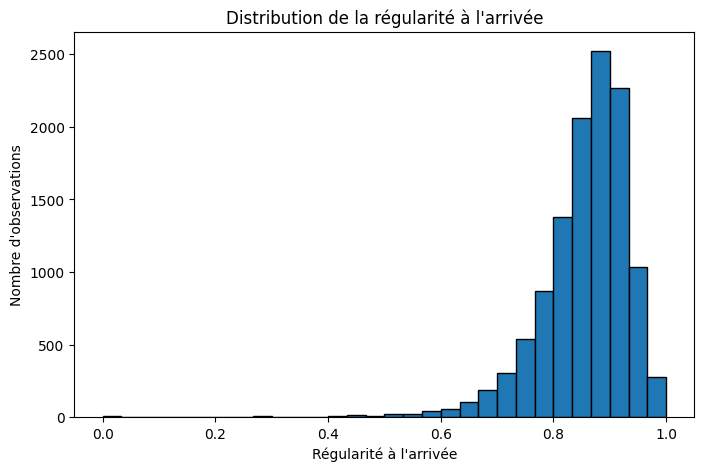

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df_analyse["regularite_arrivee"], bins=30, edgecolor="black")

plt.xlabel("Régularité à l'arrivée")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la régularité à l'arrivée")

plt.show()

La distribution de la régularité à l’arrivée est fortement concentrée sur des valeurs élevées, principalement comprises entre 0,75 et 0,95.  
Cela indique que, dans la majorité des cas, une grande proportion des trains arrive sans retard.

On observe néanmoins une certaine dispersion, avec quelques observations présentant des niveaux de régularité plus faibles.  
Ces cas plus défavorables restent minoritaires, mais suggèrent l’existence de situations particulières où la ponctualité est dégradée.

La distribution apparaît légèrement asymétrique, avec une concentration importante autour de valeurs proches de 0,85–0,90.  
Cela confirme que la régularité des TGV est globalement bonne, tout en laissant apparaître des variations qui méritent d’être expliquées.



## 5.2 Évolution de la régularité dans le temps

Nous étudions maintenant l'évolution de la régularité moyenne au fil des années.  
Cette analyse permet d’identifier d’éventuelles tendances ou ruptures dans la ponctualité des TGV.

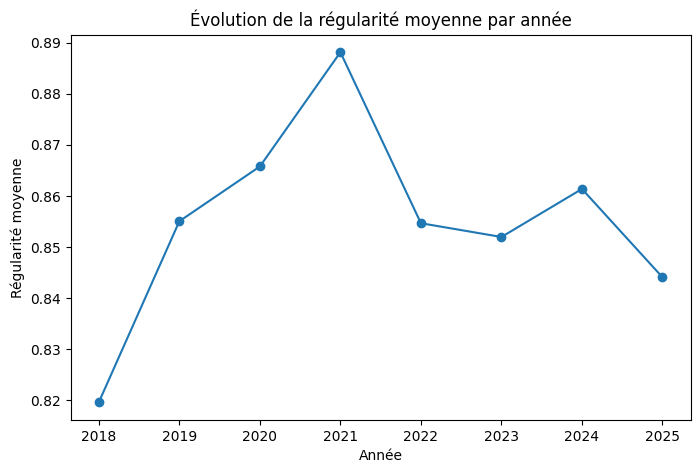

,annee,regularite_arrivee
0,2018,0.819562
1,2019,0.855028
2,2020,0.865765
3,2021,0.888158
4,2022,0.854645
5,2023,0.851946
6,2024,0.861360
7,2025,0.844055


In [29]:

regularite_par_annee = plot_regularite_moyenne(
    df_analyse,
    variable="annee",
    xlabel="Année",
    title="Évolution de la régularité moyenne par année"
)
regularite_par_annee

La régularité moyenne des TGV évolue au fil des années, avec des variations relativement marquées.

On observe d’abord une amélioration progressive de la régularité entre 2018 et 2021, avec un niveau maximal atteint autour de 2021.  
Cette période peut correspondre à une amélioration de l’exploitation ou à des conditions de trafic particulières.

À partir de 2021, une baisse de la régularité est observée. 
Les années suivantes montrent une certaine stabilisation, avec toutefois un niveau de régularité légèrement inférieur au pic observé avant la crise.

Ces résultats suggèrent que des facteurs conjoncturels peuvent avoir un impact significatif sur la ponctualité des TGV.

## 5.3 Analyse de la saisonnalité

Nous étudions maintenant la régularité moyenne en fonction du mois, afin d’identifier d’éventuels effets saisonniers.



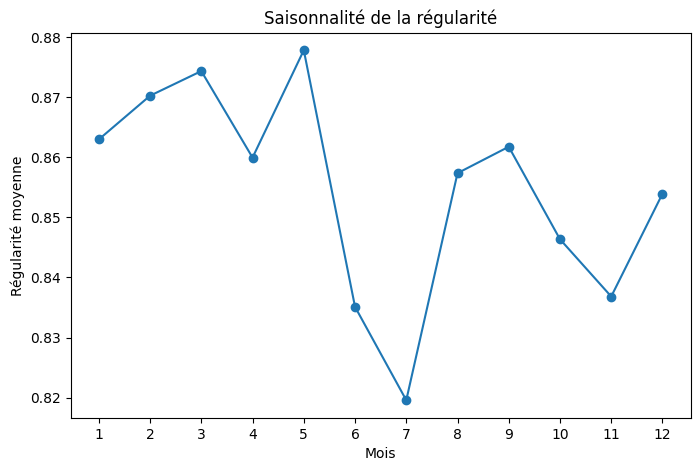

,mois,regularite_arrivee
0,1,0.862993
1,2,0.870273
2,3,0.874374
3,4,0.859964
4,5,0.877849
5,6,0.835112
6,7,0.819557
7,8,0.857373
8,9,0.861771
9,10,0.846367


In [30]:
regularite_par_mois = plot_regularite_moyenne(
    df_analyse,
    variable="mois",
    xlabel="Mois",
    title="Saisonnalité de la régularité",
    xticks=range(1, 13)
)

regularite_par_mois

On observe une variation de la régularité selon les mois, avec un niveau relativement élevé en début d’année et au printemps.

Une forte baisse apparaît en été, notamment en juillet, ce qui peut s’expliquer par une hausse du trafic et des contraintes d’exploitation.

La régularité remonte ensuite à la rentrée, avant de fluctuer légèrement en fin d’année.

Ces résultats suggèrent l’existence d’un effet saisonnier sur la ponctualité des TGV.

## 5.4 Analyse de la régularité par ligne

Nous comparons la régularité moyenne des différentes lignes ferroviaires afin d’identifier les liaisons les plus performantes ainsi que celles présentant davantage de difficultés.

Afin d’éviter de comparer des lignes observées trop rarement, nous ne retenons que les liaisons disposant d’au moins 12 observations, soit environ une observation par mois sur une année.

In [31]:

# Calcul de la régularité moyenne et du nombre d'observations par ligne
regularite_par_ligne = (
    df_analyse
    .groupby("ligne")
    .agg(
        regularite_moyenne=("regularite_arrivee", "mean"),
        nb_observations=("regularite_arrivee", "count")
    )
    .query("nb_observations >= 12")
    .round(3)
)



In [32]:
# Top 10 lignes les plus régulières
top_lignes = (
    regularite_par_ligne
    .sort_values("regularite_moyenne", ascending=False)
    .head(10)
    .reset_index()
)

# Top 10 lignes les moins régulières
bottom_lignes = (
    regularite_par_ligne
    .sort_values("regularite_moyenne", ascending=True)
    .head(10)
    .reset_index()
)

## Les lignes les plus régulières

In [33]:
GT(top_lignes).tab_header(
    title="Top 10 des lignes les plus régulières",
    subtitle="Régularité moyenne et nombre d'observations"
)


GT(_tbl_data=                                     ligne  regularite_moyenne  \
0                        PARIS EST → NANCY               0.923   
1              PARIS LYON → LYON PART DIEU               0.920   
2  BESANCON FRANCHE COMTE TGV → PARIS LYON               0.917   
3                    LAUSANNE → PARIS LYON               0.915   
4         TOURCOING → MARSEILLE ST CHARLES               0.915   
5                 RENNES → PARIS VAUGIRARD               0.914   
6               PARIS MONTPARNASSE → BREST               0.912   
7                 PARIS LYON → DIJON VILLE               0.911   
8               BREST → PARIS MONTPARNASSE               0.910   
9   PARIS MONTPARNASSE → LA ROCHELLE VILLE               0.909   

   nb_observations  
0               96  
1               96  
2               96  
3               95  
4               13  
5               12  
6               96  
7               99  
8               96  
9               95  , _body=<great_tables._gt_data.Body object at 0x7f4768207230>, _boxhead=Boxhead([ColInfo(var='ligne', type=<ColInfoTypeEnum.default: 1>, column_label='ligne', column_align='left', column_width=None), ColInfo(var='regularite_moyenne', type=<ColInfoTypeEnum.default: 1>, column_label='regularite_moyenne', column_align='right', column_width=None), ColInfo(var='nb_observations', type=<ColInfoTypeEnum.default: 1>, column_label='nb_observations', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f4768206270>, _spanners=Spanners([]), _heading=Heading(title='Top 10 des lignes les plus régulières', subtitle="Régularité moyenne et nombre d'observations", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f4768206e40>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f4767a50910>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f47682074d0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(s

## Les lignes les moins régulières

Après avoir identifié les lignes les plus régulières, nous examinons les liaisons présentant les niveaux de régularité les plus faibles.

Cette analyse permet de repérer les lignes les plus exposées aux difficultés d’exploitation ou aux retards.

In [34]:
GT(bottom_lignes).tab_header(
    title="Top 10 des lignes les moins régulières",
    subtitle="Régularité moyenne et nombre d'observations"
)

GT(_tbl_data=                                    ligne  regularite_moyenne  nb_observations
0                     ITALIE → PARIS LYON               0.686               91
1  CHAMBERY CHALLES LES EAUX → PARIS LYON               0.731               98
2                MACON LOCHE → PARIS LYON               0.744               99
3                  LYON PART DIEU → LILLE               0.745               96
4        LYON PART DIEU → MARNE LA VALLEE               0.759               95
5                      ARRAS → PARIS NORD               0.780               96
6   LYON PART DIEU → MARSEILLE ST CHARLES               0.783               99
7            LE MANS → PARIS MONTPARNASSE               0.784               96
8            MARSEILLE ST CHARLES → LILLE               0.785               95
9                      DOUAI → PARIS NORD               0.785               96, _body=<great_tables._gt_data.Body object at 0x7f4767bc8770>, _boxhead=Boxhead([ColInfo(var='ligne', type=<ColInfoTypeEnum.default: 1>, column_label='ligne', column_align='left', column_width=None), ColInfo(var='regularite_moyenne', type=<ColInfoTypeEnum.default: 1>, column_label='regularite_moyenne', column_align='right', column_width=None), ColInfo(var='nb_observations', type=<ColInfoTypeEnum.default: 1>, column_label='nb_observations', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f4767a50e10>, _spanners=Spanners([]), _heading=Heading(title='Top 10 des lignes les moins régulières', subtitle="Régularité moyenne et nombre d'observations", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f4767a511d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f4767bc89d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f4767a51310>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=

Des écarts de régularité apparaissent entre les lignes retenues. Certaines liaisons présentent des niveaux de ponctualité nettement plus élevés que d’autres.
Les lignes internationales ou passant par des nœuds ferroviaires importants semblent souvent moins régulières, ce qui peut refléter une plus grande complexité d’exploitation.
Ces résultats doivent toutefois être interprétés à la lumière du nombre d’observations disponible pour chaque liaison.

## 5.5 Lien entre les causes de retard et la régularité

Nous étudions la relation entre les différentes causes de retard et la régularité à l’arrivée.

Cette analyse permet d’identifier les facteurs les plus fortement associés à une dégradation de la ponctualité.

In [35]:
variables_corr = [
    "regularite_arrivee",
    "pct_cause_retard_externe",
    "pct_cause_retard_infrastructure",
    "pct_cause_retard_gestion_trafic",
    "pct_cause_retard_materiel_roulant",
    "pct_cause_retard_gestion_gare",
    "pct_cause_retard_voyageurs"
]

corr_matrix = df_analyse[variables_corr].corr()
corr_matrix

,regularite_arrivee,pct_cause_retard_externe,pct_cause_retard_infrastructure,pct_cause_retard_gestion_trafic,pct_cause_retard_materiel_roulant,pct_cause_retard_gestion_gare,pct_cause_retard_voyageurs
regularite_arrivee,1.000000,-0.020494,-0.047677,-0.192379,0.130502,0.035330,0.099672
pct_cause_retard_externe,-0.020494,1.000000,-0.186907,-0.281201,-0.247561,-0.200003,-0.188952
pct_cause_retard_infrastructure,-0.047677,-0.186907,1.000000,-0.222886,-0.238138,-0.178637,-0.164676
pct_cause_retard_gestion_trafic,-0.192379,-0.281201,-0.222886,1.000000,-0.187239,-0.090947,-0.122937
pct_cause_retard_materiel_roulant,0.130502,-0.247561,-0.238138,-0.187239,1.000000,0.004153,-0.103140
pct_cause_retard_gestion_gare,0.035330,-0.200003,-0.178637,-0.090947,0.004153,1.000000,0.054943
pct_cause_retard_voyageurs,0.099672,-0.188952,-0.164676,-0.122937,-0.103140,0.054943,1.000000


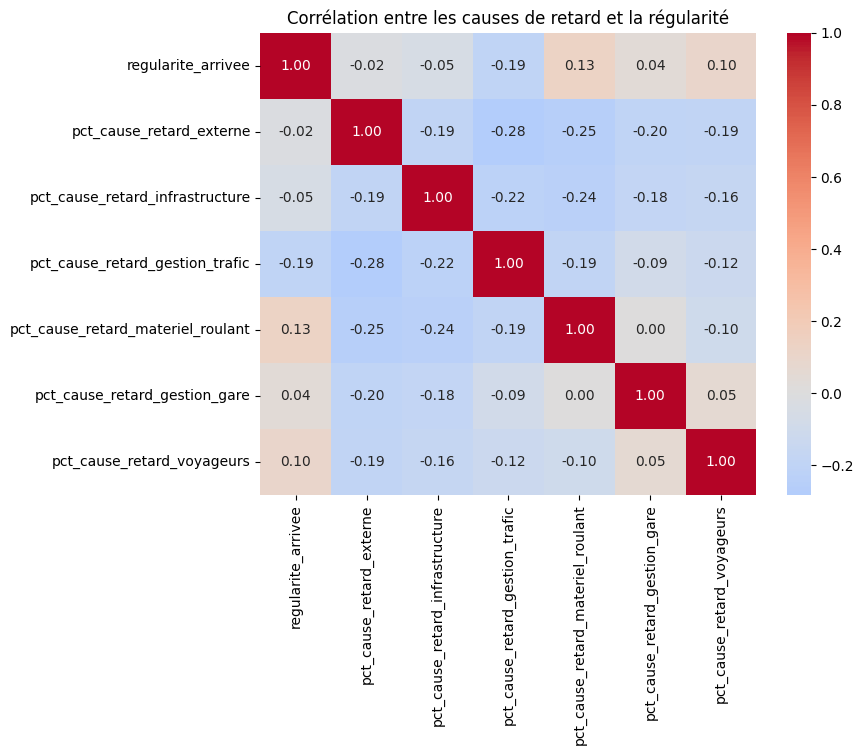

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Corrélation entre les causes de retard et la régularité")
plt.show()

Les corrélations observées entre la régularité à l’arrivée et les différentes causes de retard restent globalement faibles.
La part des retards attribuée à la gestion du trafic présente l’association négative la plus marquée avec la régularité, mais cet effet demeure modéré.

Les autres causes affichent des corrélations proches de zéro, ce qui suggère qu’aucune d’entre elles, prise isolément, n’explique fortement la ponctualité des TGV.

Ces résultats doivent toutefois être interprétés avec prudence, car les variables de causes sont exprimées en pourcentages et se répartissent un même total.
Ils suggèrent surtout que la régularité dépend d’un ensemble de facteurs imbriqués plutôt que d’une cause unique.

## 5.6 Analyse de la régularité selon le type de service

Nous étudions si la régularité varie selon le type de service (national ou international), afin d’identifier d’éventuelles différences liées à la nature des trajets.


In [37]:
df_analyse["service"].sort_values().unique()

array(['International', 'National'], dtype=object)

In [38]:
regularite_par_service = (
    df_analyse.groupby("service")["regularite_arrivee"]
    .mean()
)

regularite_par_service

service
International    0.842215
National         0.856373
Name: regularite_arrivee, dtype: float64

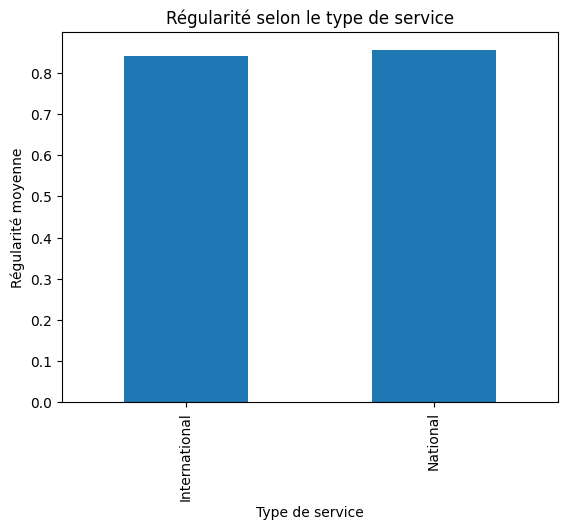

In [39]:
regularite_par_service.plot(kind="bar")

plt.ylabel("Régularité moyenne")
plt.xlabel("Type de service")
plt.title("Régularité selon le type de service")
plt.show()

On observe que les trajets internationaux présentent en moyenne une régularité légèrement inférieure à celle des trajets nationaux.

Cet écart reste modéré, mais il peut refléter une plus grande complexité d’exploitation, liée notamment à des trajets plus longs et à la coordination entre plusieurs réseaux ferroviaires.

Le type de service semble donc associé à la régularité, sans constituer à lui seul un facteur explicatif suffisant.

# 6-Modélisation

## 6.1 Choix du modèle

Nous avons choisi d’utiliser un modèle de type Random Forest pour la modélisation de la régularité.

Ce choix s’explique par la nature des données, qui incluent des variables complexes et potentiellement non linéaires, notamment la variable "ligne" comportant un grand nombre de modalités.

Contrairement à la régression linéaire, la Random Forest permet de mieux capturer ces relations et d’obtenir de meilleures performances prédictives.

Le modèle Random Forest est donc retenu comme modèle principal dans cette étude.

## 6.2 Modélisation avec Random Forest

Nous estimons un modèle de type Random Forest afin de capturer des relations non linéaires et d’améliorer la performance prédictive.

Contrairement à la régression linéaire, ce modèle est plus flexible et peut mieux exploiter des variables complexes comme la variable "ligne".

Nous sélectionnons explicitement les variables retenues pour la modélisation afin d’écarter les colonnes redondantes ou peu informatives.
Nous distinguons les variables numériques et les variables catégorielles qui seront traitées différemment dans le pipeline de prétraitement.

In [40]:
# Variable cible
y = df_analyse["regularite_arrivee"]

# Sélection des variables explicatives numériques
numeric_features = [
    "duree_moyenne_trajet",
    "circulations_prevues",
    "taux_annulation",
    "pct_cause_retard_externe",
    "pct_cause_retard_infrastructure",
    "pct_cause_retard_gestion_trafic",
    "pct_cause_retard_materiel_roulant",
    "pct_cause_retard_gestion_gare",
    "pct_cause_retard_voyageurs"
]

# Sélection des variables explicatives catégorielles
categorical_features = [
    "service",
    "saison",
    "ligne"
]

# Construction de la matrice explicative
features_modele = numeric_features + categorical_features

X = df_analyse[features_modele].copy()


In [41]:
# Séparation de l'échantillon en données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
# Pipeline de prétraitement pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Pipeline de prétraitement pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combinaison des prétraitements
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [43]:
model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [44]:
# Entraînement du modèle
model_rf.fit(X_train, y_train) 

# Prédiction sur l'échantillon test
y_pred_rf = model_rf.predict(X_test)

La modélisation suit les étapes classiques d’un apprentissage supervisé avec scikit-learn.
Après avoir exploré et préparé les données, nous sélectionnons les variables explicatives, puis nous séparons l’échantillon en un ensemble d’entraînement et un ensemble de test.

Les variables catégorielles sont encodées par one-hot encoding dans le pipeline de prétraitement, tandis que les variables numériques sont simplement imputées si nécessaire.
La normalisation n’a pas été retenue ici, car le modèle Random Forest n’y est pas sensible.

Le modèle est ensuite entraîné sur l’échantillon d’apprentissage, puis appliqué à l’échantillon test afin d’évaluer sa capacité de généralisation.

## 6.3 Évaluation du modèle

In [45]:
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

In [46]:
print(f"MAE : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R² : {r2:.4f}")

MAE : 0.0401
RMSE : 0.0647
R² : 0.4225


Le modèle présente des performances correctes, avec un pouvoir explicatif modéré (R² ≈ 0,42). Il capte donc une partie substantielle de la variabilité de la régularité, sans toutefois l’expliquer complètement.

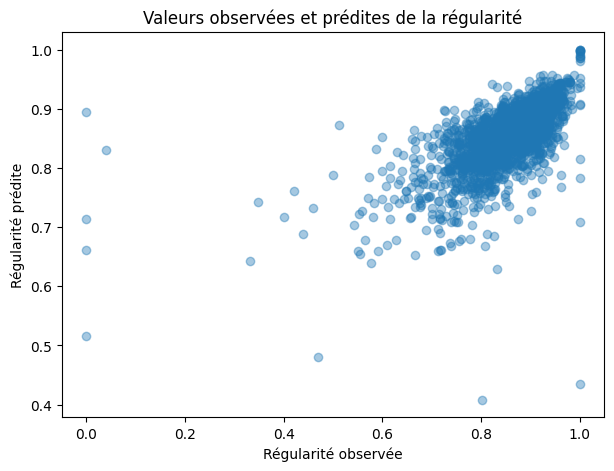

In [48]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.xlabel("Régularité observée")
plt.ylabel("Régularité prédite")
plt.title("Valeurs observées et prédites de la régularité")
plt.show()

Ce graphique permet de comparer les valeurs observées et les valeurs prédites de la régularité à l’arrivée.
On observe une relation globalement croissante entre les deux, ce qui indique que le modèle parvient à restituer la tendance générale des données.

La majorité des observations est concentrée sur des niveaux élevés de régularité, entre 0,75 et 0,95, ce qui est cohérent avec la distribution observée précédemment.
Le nuage de points reste toutefois dispersé, et quelques prédictions s’éloignent sensiblement des valeurs observées.

Ce résultat confirme que le modèle possède une capacité prédictive correcte, tout en conservant une marge d’erreur non négligeable, ce qui est cohérent avec un pouvoir explicatif modéré

## 6.4 Importance des variables

In [47]:
rf = model_rf.named_steps["regressor"]
feature_names = model_rf.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "variable": feature_names,
    "importance": rf.feature_importances_
})

# Nettoyage des noms de variables
importance_df["variable"] = (
    importance_df["variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Regroupement des variables catégorielles encodées
importance_df["variable_groupee"] = importance_df["variable"].apply(
    lambda x: "service" if x.startswith("service_")
    else "saison" if x.startswith("saison_")
    else "ligne" if x.startswith("ligne_")
    else x
)

importance_agregee = (
    importance_df.groupby("variable_groupee", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

importance_agregee.head(10)

,variable_groupee,importance
2,ligne,0.239769
0,circulations_prevues,0.105016
5,pct_cause_retard_gestion_trafic,0.104722
3,pct_cause_retard_externe,0.094625
11,taux_annulation,0.083720
1,duree_moyenne_trajet,0.082910
4,pct_cause_retard_gestion_gare,0.069908
6,pct_cause_retard_infrastructure,0.063403
8,pct_cause_retard_voyageurs,0.054057
7,pct_cause_retard_materiel_roulant,0.048593


L’analyse des importances agrégées issues du modèle Random Forest met en évidence les variables les plus influentes dans l’explication de la régularité des TGV.

La variable ligne apparaît comme la plus importante, ce qui suggère que la liaison ferroviaire considérée joue un rôle central dans la ponctualité observée. Autrement dit, certaines lignes semblent structurellement plus exposées aux retards que d’autres.

Parmi les variables numériques, le volume de circulations prévues, la part des retards liés à la gestion du trafic et la part des causes externes ressortent comme particulièrement influents. La durée moyenne du trajet et le taux d’annulation jouent également un rôle non négligeable.

Ces résultats suggèrent que la régularité dépend à la fois de caractéristiques propres aux lignes ferroviaires, de facteurs opérationnels liés à l’exploitation du réseau, et de facteurs externes. Ils confirment ainsi la complexité du phénomène étudié.

## 6.5 Limites de l’étude

Cette étude repose sur les variables disponibles dans la base SNCF, qui ne prennent pas en compte certains facteurs potentiellement importants comme la météo, les mouvements sociaux ou des informations plus fines sur l’état du réseau.  
Par ailleurs, les causes de retard sont exprimées en pourcentages d’un même total, ce qui rend leur interprétation plus délicate.  
Les résultats doivent donc être compris comme une analyse des facteurs associés à la régularité, et non comme une démonstration causale stricte.

# 7-Conclusion

Dans ce projet, nous avons étudié les facteurs associés à la régularité des TGV en France à partir de données mensuelles publiées par la SNCF.

L’analyse descriptive a montré que la régularité est globalement élevée, mais qu’elle varie selon les périodes, les lignes et les conditions d’exploitation.

La modélisation par Random Forest a permis d’identifier les variables les plus influentes dans l’explication de la régularité. La liaison ferroviaire considérée joue un rôle central, ce qui suggère que certaines lignes sont structurellement plus exposées aux retards que d’autres. Le volume de circulations, la gestion du trafic, les causes externes, la durée moyenne du trajet et le taux d’annulation apparaissent également comme des facteurs importants.

Ces résultats mettent en évidence la complexité de la ponctualité ferroviaire, qui dépend à la fois de caractéristiques propres aux lignes, de facteurs opérationnels et de contraintes externes. Ils suggèrent que l’amélioration de la régularité passe non seulement par une meilleure gestion de l’exploitation, mais aussi par une prise en compte des spécificités de chaque liaison.